<a href="https://colab.research.google.com/github/Vaibhavi7179/House-Price-Regression/blob/main/AI_Powered_Energy_Consumption_Forecasting_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

AI-Powered Energy Consumption Forecasting System

CELL 1 — Import

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

CELL 2 — Load Dataset

In [ ]:
data = pd.read_csv('energy_dataset.csv', parse_dates=['Datetime'], index_col='Datetime')

data = data.resample('H').mean()
data = data.fillna(method='ffill')

data.head()

/tmp/ipykernel_3943/2408022435.py:3: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  data = data.resample('H').mean()
/tmp/ipykernel_3943/2408022435.py:4: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data = data.fillna(method='ffill')


,Energy
Datetime,
2024-01-01 00:00:00,77.19
2024-01-01 01:00:00,83.55
2024-01-01 02:00:00,93.44
2024-01-01 03:00:00,94.80
2024-01-01 04:00:00,101.46


CELL 3 — Visualization

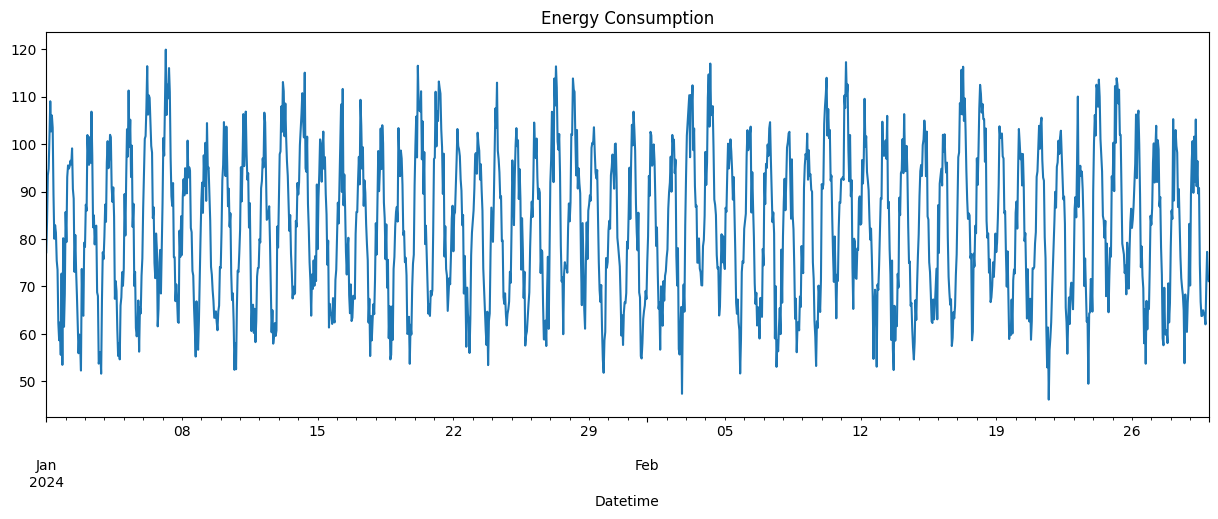

In [ ]:
data['Energy'].plot(figsize=(15,5), title="Energy Consumption")
plt.show()

CELL 4 — Feature Engineering

In [ ]:
data['hour'] = data.index.hour
data['day'] = data.index.dayofweek

CELL 5 — Prepare Data

In [ ]:
from sklearn.model_selection import train_test_split

X = data[['hour', 'day']]
y = data['Energy']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

CELL 6 — Train Model

In [ ]:
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error

model = MLPRegressor(hidden_layer_sizes=(64,64), max_iter=500)
model.fit(X_train, y_train)

pred = model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, pred))

MAE: 4.64426197036006


CELL 7 — Visualization (Actual vs Predicted)

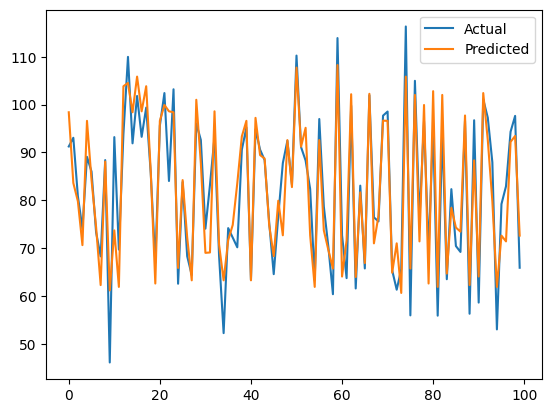

In [ ]:
plt.plot(y_test.values[:100], label='Actual')
plt.plot(pred[:100], label='Predicted')
plt.legend()
plt.show()

CELL 8 — Save Model

In [ ]:
import joblib
joblib.dump(model, 'energy_model.pkl')

['energy_model.pkl']

UI FOR PREDICTION

In [ ]:
import ipywidgets as widgets
from IPython.display import display
import numpy as np

# Create input fields
hour_input = widgets.IntSlider(
    value=12,
    min=0,
    max=23,
    step=1,
    description='Hour:',
    style={'description_width': 'initial'}
)

day_input = widgets.IntSlider(
    value=3,
    min=0,
    max=6,
    step=1,
    description='Day (0=Mon, 6=Sun):',
    style={'description_width': 'initial'}
)

# Button
predict_button = widgets.Button(description="Predict Energy")

# Output
output = widgets.Output()

# Prediction function
def predict_energy(b):
    with output:
        output.clear_output()

        hour = hour_input.value
        day = day_input.value

        prediction = model.predict([[hour, day]])

        print("⚡ Predicted Energy Consumption:", round(prediction[0], 2))

# Button click event
predict_button.on_click(predict_energy)

# Display UI
display(hour_input, day_input, predict_button, output)

IntSlider(value=12, description='Hour:', max=23, style=SliderStyle(description_width='initial'))

IntSlider(value=3, description='Day (0=Mon, 6=Sun):', max=6, style=SliderStyle(description_width='initial'))

Button(description='Predict Energy', style=ButtonStyle())

Output()